 # Анализ пользовательского поведения и бизнес-гипотез

## Цель проекта

Оценить влияние подписной модели на поведение и экономическую ценность пользователей, определить точки роста выручки и сформировать рекомендации по развитию продукта.

## Задачи проекта

- Провести исследовательский анализ данных о пользователях и их поездках.
- Сравнить поведение пользователей с подпиской и без подписки.
- Рассчитать и сравнить месячную выручку разных групп пользователей.
- Сформулировать и статистически проверить бизнес-гипотезы.
- Оценить практическую значимость полученных результатов.
- Сформулировать аналитические выводы и рекомендации.

# Описание данных

**Таблица с пользователями**`users_go.csv`

* `user_id` — уникальный идентификатор пользователя.

* `name` — имя пользователя.

* `age` — возраст.

* `city` — город.

* `subscription_type` — тип подписки: free, ultra.

**Таблица с поездками** `rides_go.csv`

* `user_id` — уникальный идентификатор пользователя.

* `distance` — расстояние в метрах, которое пользователь проехал в текущей сессии.

* `duration` — продолжительность сессии в минутах, то есть время с того момента, как пользователь нажал кнопку «Начать поездку», до того, как он нажал кнопку «Завершить поездку».

* `date` — дата совершения поездки.

**Таблица с подписками** `subscriptions_go.csv`

* `subscription_type` — тип подписки.

* `minute_price` — стоимость одной минуты поездки по этой подписке.

* `start_ride_price` — стоимость начала поездки.

* `subscription_fee` — стоимость ежемесячного платежа.

# 1. Загрузка данных и вывод общей информации

In [1]:
import pandas as pd

In [2]:
df_users_go = pd.read_csv('https://code.s3.yandex.net/datasets/users_go.csv')
df_rides_go = pd.read_csv('https://code.s3.yandex.net/datasets/rides_go.csv')
df_subscriptions_go = pd.read_csv('https://code.s3.yandex.net/datasets/subscriptions_go.csv')

In [3]:
# вывод 5 строк каждого датафрейма
dataframes = {"df_users_go": df_users_go,
              "df_rides_go": df_rides_go,
              "df_subscriptions_go": df_subscriptions_go}

for name, df in dataframes.items():
    print()
    print(f'Название таблицы: {name}')
    display(df.head(5))


Название таблицы: df_users_go


,user_id,name,age,city,subscription_type
0,1,Кира,22,Тюмень,ultra
1,2,Станислав,31,Омск,ultra
2,3,Алексей,20,Москва,ultra
3,4,Константин,26,Ростов-на-Дону,ultra
4,5,Адель,28,Омск,ultra



Название таблицы: df_rides_go


,user_id,distance,duration,date
0,1,4409.919140,25.599769,2021-01-01
1,1,2617.592153,15.816871,2021-01-18
2,1,754.159807,6.232113,2021-04-20
3,1,2694.783254,18.511000,2021-08-11
4,1,4028.687306,26.265803,2021-08-28



Название таблицы: df_subscriptions_go


,subscription_type,minute_price,start_ride_price,subscription_fee
0,free,8,50,0
1,ultra,6,0,199


In [4]:
# Подсчет строк по датафреймам
for i in (df_users_go, df_rides_go, df_subscriptions_go):
    print(i.shape[0], end = " ")

1565 18068 2 

# 2. Знакомство с данными и их предварительная подготовка

In [5]:
df_rides_go.dtypes

user_id       int64
distance    float64
duration    float64
date         object
dtype: object

In [6]:
# Преобразование формата даты в df_rides_go
df_rides_go['date'] = pd.to_datetime(df_rides_go['date'])
print(df_rides_go["date"].dtype)

datetime64[ns]


In [7]:
# Создаем столбец month
df_rides_go['month'] = df_rides_go['date'].dt.month
df_rides_go[['month']].head(5)

,month
0,1
1,1
2,4
3,8
4,8


In [8]:
# Поиск дублей и пропусков
print(f'Количество пропусков: {df_users_go.isna().sum().sum()}') 
print(f'Количество дублей: {df_users_go.duplicated().sum()}')

Количество пропусков: 0
Количество дублей: 31


In [9]:
# удаление дублей
df_users_go.drop_duplicates(inplace=True)
df_users_go.duplicated().sum()

np.int64(0)

In [10]:
# Округление длительности поездки
df_rides_go['duration'] = df_rides_go['duration'].round()
df_rides_go['duration'] = df_rides_go['duration'].astype('int')
df_rides_go['duration'].head(5)

0    26
1    16
2     6
3    19
4    26
Name: duration, dtype: int64

# 3. Исследовательский анализ данных (EDA)

In [11]:
import matplotlib.pyplot as plt

In [12]:
# Количество пользователей по городам.
users_by_city_count = df_users_go['city'].value_counts()
users_by_city_count

city
Пятигорск         219
Екатеринбург      204
Ростов-на-Дону    198
Краснодар         193
Сочи              189
Омск              183
Тюмень            180
Москва            168
Name: count, dtype: int64

In [13]:
# Количество пользователей подписки
subscription_type_count = df_users_go['subscription_type'].value_counts()
subscription_type_count

subscription_type
free     835
ultra    699
Name: count, dtype: int64

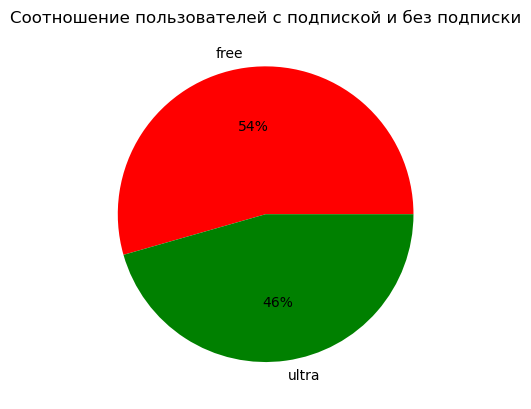

In [14]:
# Круговая диаграмма по подпискам
subscription_type_count.plot(
    kind= 'pie' ,
    title='Соотношение пользователей с подпиской и без подписки',
    autopct= '%.0f%%',
    ylabel= '' ,
    colors= ['red', 'green'])

plt.show()

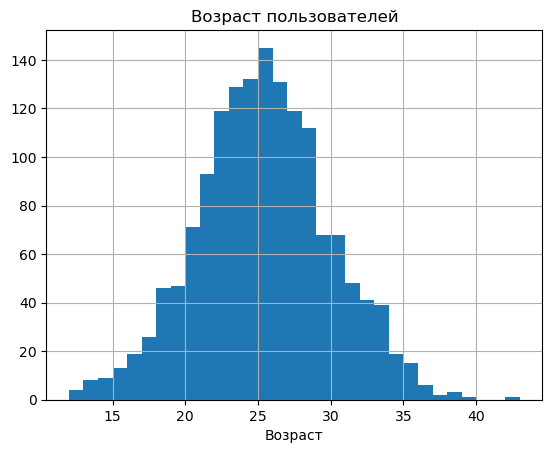

In [15]:
# Распределяем по возросту, строим гистограму
n_bins = df_users_go['age'].max() - df_users_go['age'].min()

df_users_go['age'].hist(bins = n_bins)

plt.title('Возраст пользователей')
plt.xlabel('Возраст')
plt.show()

In [16]:
# Определяем долю несовершеннолетних пользователей
users_under_18_ratio = round(df_users_go.loc[df_users_go['age']< 18, 'user_id'].count() / df_users_go['age'].count()*100)  
print(f'Доля несовершеннолетних пользователей самокатов составляет {users_under_18_ratio}%.')

Доля несовершеннолетних пользователей самокатов составляет 5%.


In [17]:
# Характеристики длительности поездки
duration_mean = int(round(df_rides_go['duration'].mean()))
duration_std = int(round(df_rides_go['duration'].std()))

duration_pct25 = int(round(df_rides_go['duration'].quantile(0.25)))
duration_pct75 = int(round(df_rides_go['duration'].quantile(0.75)))

print(f'Средняя длительность поездки {duration_mean} минут со стандартным отклонением {duration_std}. Основная часть поездок занимает от {duration_pct25} до {duration_pct75} минут.')

Средняя длительность поездки 18 минут со стандартным отклонением 6. Основная часть поездок занимает от 14 до 22 минут.


# 4. Объединение данных

In [18]:
# Объединение таблицы df_users_go и df_rides_go
df = df_users_go.merge(df_rides_go, on = 'user_id', how = 'left')

In [19]:
# Присоединение df_subscriptions_go
df = df.merge(df_subscriptions_go, on = 'subscription_type', how = 'left')

In [20]:
# Выводим первые строки датафрейма
display(df.head(5))

# Выводим количество строк и столбцов в объединённом датафрейме
n_rows, n_cols = df.shape
print(f'В полученном датафрейме {n_rows} строк и {n_cols} столбцов.')

,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
0,1,Кира,22,Тюмень,ultra,4409.919140,26,2021-01-01,1,6,0,199
1,1,Кира,22,Тюмень,ultra,2617.592153,16,2021-01-18,1,6,0,199
2,1,Кира,22,Тюмень,ultra,754.159807,6,2021-04-20,4,6,0,199
3,1,Кира,22,Тюмень,ultra,2694.783254,19,2021-08-11,8,6,0,199
4,1,Кира,22,Тюмень,ultra,4028.687306,26,2021-08-28,8,6,0,199


В полученном датафрейме 18068 строк и 12 столбцов.


In [21]:
# Отдельные датафреймы для пользователей с подпиской и без
df_ultra = df.loc[df['subscription_type'] == 'ultra']
df_free = df.loc[df['subscription_type'] == 'free']

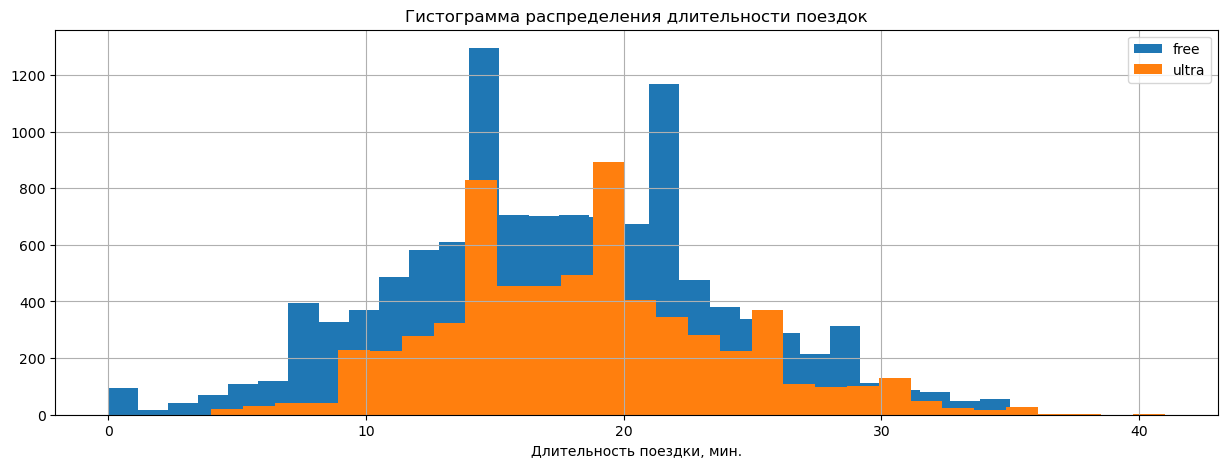

Средняя длительность поездки для пользователей без подписки 17 мин, а для пользователей с подпиской 19 мин


In [22]:
# Гистограмма длительности поездки для пользователей с подпиской и без
plt.figure(figsize=(15, 5))

df_free['duration'].hist(bins = 30, label = 'free')
df_ultra['duration'].hist(bins = 30, label = 'ultra')

plt.xlabel('Длительность поездки, мин.')
plt.title('Гистограмма распределения длительности поездок')
plt.legend()

plt.show()

# Расчет и вывод на экран средней длительности поездки для пользователей с подпиской и без
mean_duration_free = round(df_free['duration'].mean())
mean_duration_ultra = round(df_ultra['duration'].mean())
print(f'Средняя длительность поездки для пользователей без подписки {mean_duration_free} мин, а для пользователей с подпиской {mean_duration_ultra} мин')

# 5. Анализ выручки

In [23]:
# Группируем данные по нужным колонкам
df_gp = df.groupby(['user_id', 'name', 'subscription_type', 'month'], as_index=False)

# Подсчёт агрегированных метрик
df_agg = df_gp.agg(
    total_distance=('distance', 'sum'),
    total_duration=('duration', 'sum'),
    rides_count= ('duration', 'count'),
    subscription_type= ('subscription_type', 'first'),
    minute_price= ('minute_price', 'first'),
    start_ride_price= ('start_ride_price', 'first'),
    subscription_fee= ('subscription_fee', 'first')
)
df_agg.head()

,user_id,name,month,total_distance,total_duration,rides_count,subscription_type,minute_price,start_ride_price,subscription_fee
0,1,Кира,1,7027.511294,42,2,ultra,6,0,199
1,1,Кира,4,754.159807,6,1,ultra,6,0,199
2,1,Кира,8,6723.470560,45,2,ultra,6,0,199
3,1,Кира,10,5809.911100,32,2,ultra,6,0,199
4,1,Кира,11,7003.499363,53,3,ultra,6,0,199


In [24]:
# Функция для подсчёта выручки по каждой строке
def calculate_monthly_revenue(row):
    monthly_revenue = (
        row['start_ride_price'] * row['rides_count']
        + row['minute_price'] * row['total_duration']
        + row['subscription_fee'])
    return monthly_revenue

In [25]:
# Создание столбца с месячной выручкой на пользователя
df_agg['monthly_revenue'] = df_agg.apply(calculate_monthly_revenue, axis = 1)
df_agg.head()

,user_id,name,month,total_distance,total_duration,rides_count,subscription_type,minute_price,start_ride_price,subscription_fee,monthly_revenue
0,1,Кира,1,7027.511294,42,2,ultra,6,0,199,451
1,1,Кира,4,754.159807,6,1,ultra,6,0,199,235
2,1,Кира,8,6723.470560,45,2,ultra,6,0,199,469
3,1,Кира,10,5809.911100,32,2,ultra,6,0,199,391
4,1,Кира,11,7003.499363,53,3,ultra,6,0,199,517


In [26]:
# Поиск пользователя с максимальной выручкой
max_revenue = df_agg.groupby('user_id')['monthly_revenue'].sum().sort_values(ascending=False).idxmax()
top_user = df_agg.loc[df_agg['user_id'] == max_revenue]
top_user[['user_id', 'name', 'month', 'rides_count','monthly_revenue']]

,user_id,name,month,rides_count,monthly_revenue
8877,1236,Александр,1,2,228
8878,1236,Александр,2,3,614
8879,1236,Александр,3,5,762
8880,1236,Александр,4,1,202
8881,1236,Александр,5,3,574
8882,1236,Александр,6,1,282
8883,1236,Александр,7,1,290
8884,1236,Александр,8,2,452
8885,1236,Александр,9,1,122
8886,1236,Александр,10,3,430


# 6. Проверка гипотез

In [27]:
import scipy.stats as st

In [28]:
# Создаем функцию для вывода результатов статистического анализа гипотез
def print_stattest_results(p_value:float, alpha:float = 0.05):
    if p_value < alpha:
        print(f"Полученное значение p_value={p_value} меньше критического уровня alpha={alpha}. Принимаем альтернативную гипотезу.")
    else:
        print(f"Полученное значение p_value={p_value} больше критического уровня alpha={alpha}. Опровергнуть нулевую гипотезу нельзя.")

# Проверка формулы
print_stattest_results(p_value=0.0001)
print_stattest_results(p_value=0.1)

Полученное значение p_value=0.0001 меньше критического уровня alpha=0.05. Принимаем альтернативную гипотезу.
Полученное значение p_value=0.1 больше критического уровня alpha=0.05. Опровергнуть нулевую гипотезу нельзя.


## Длительность для пользователей с подпиской и без

### `Тратят ли пользователи с подпиской больше времени на поездки?`

* Нулевая гипотеза (Н0): Среднее время поездки у пользователей с подпиской и без подписки одинаковое.
* Альтернативная гипотеза (Н1): Среднее время поездки у пользователей с подпиской больше, чем у пользователей без подписки.

In [29]:
ultra_duration = df_ultra['duration']
free_duration = df_free['duration']

results = st.ttest_ind(ultra_duration, free_duration, alternative= 'greater') 
p_value = results.pvalue
print_stattest_results(p_value)

ultra_mean_duration = round(df_ultra['duration'].mean(),2)
free_mean_duration = round(df_free['duration'].mean(),2)

print(f'Средняя длительность поездки тарифа Ultra {ultra_mean_duration}')
print(f'Средняя длительность поездки тарифа Free {free_mean_duration}')

Полученное значение p_value=3.1600689435611813e-35 меньше критического уровня alpha=0.05. Принимаем альтернативную гипотезу.
Средняя длительность поездки тарифа Ultra 18.55
Средняя длительность поездки тарифа Free 17.39


## Длительность поездки: больше или меньше критического значения

### `Можно ли сказать, что расстояние, которое проезжают пользователи с подпиской за одну поездку, больше 3130 метров?`

* Нулевая гипотеза (Н0): Средняя дистанция поездки у пользователей с подпиской равна 3130 м.
* Альтернативная гипотеза (Н1): Средняя дистанция поездки у пользователей с подпиской больше 3130 м.

In [30]:
null_hypothesis = 3130
ultra_distance = df_ultra['distance']

results = st.ttest_1samp(ultra_distance, null_hypothesis, alternative = 'greater')
p_value = results.pvalue 
print_stattest_results(p_value)

Полученное значение p_value=0.9195368847849785 больше критического уровня alpha=0.05. Опровергнуть нулевую гипотезу нельзя.


## Прибыль от пользователей с подпиской и без

### `Выручка от пользователей с подпиской выше, чем выручка от пользователей без подписки ?`

* Нулевая гипотеза (Н0): Средняя месячная выручка у пользователей с подпиской и без подписки одинаковая.
* Альтернативная гипотеза (Н1): Средняя месячная выручка у пользователей с подпиской выше, чем у пользователей без подписки.

In [31]:
revenue_ultra = df_agg.loc[df_agg['subscription_type'] == 'ultra']['monthly_revenue']
revenue_free = df_agg.loc[df_agg['subscription_type'] == 'free']['monthly_revenue']

results = st.ttest_ind(revenue_ultra, revenue_free, alternative ='greater')
p_value = results.pvalue
print_stattest_results(p_value)

mean_revenue_ultra = round(revenue_ultra.mean())
mean_revenue_free = round(revenue_free.mean())

print(f'Средняя выручка подписчиков Ultra {mean_revenue_ultra} руб')
print(f'Средняя выручка подписчиков Free {mean_revenue_free} руб')

Полученное значение p_value=1.7274069878387966e-37 меньше критического уровня alpha=0.05. Принимаем альтернативную гипотезу.
Средняя выручка подписчиков Ultra 359 руб
Средняя выручка подписчиков Free 322 руб


# 7. Вероятностная оценка бизнес-гипотез

## Расчёт выборочного среднего и стандартного отклонения

Рассматривается возможность предоставления дополнительной скидки пользователям с подпиской, совершающим длительные поездки продолжительностью более 30 минут. Необходимо определить долю таких поездок среди всех поездок пользователей с подпиской и оценить потенциальный охват программы.

In [32]:
# Вычисляем среднее значение
mu = df_ultra['duration'].mean()

# Вычисляем стандартное отклонение
sigma = df_ultra['duration'].std()

# Задаём целевое время
target_time =30

# Делаем вывод
print(f'Средняя длительность поездки {round(mu, 1)}, стандартное отклонение {round(sigma, 1)}.')

Средняя длительность поездки 18.5, стандартное отклонение 5.6.


## Вычисление значения функции распределения в точке (CDF)

In [33]:
# Вычисляем вероятность того, что случайная величина будет меньше указанного значения или равна ему

duration_norm_dist  = st.norm(mu, sigma)

prob = round(1 - duration_norm_dist.cdf(target_time), 3) 

print(f'Вероятность поездки более 30 минут {prob}')

Вероятность поездки более 30 минут 0.02


## Вероятность для интервала (CDF)

Процент пользователей, для которых будет показана скидка, недостаточно большой и вряд ли поможет в увеличении лояльности клиентов. Расширяем интервал и опредляем, `какой процент пользователей совершает поездки в интервале от 20 до 30 минут ?`

In [34]:
# Определяем границы интервала
low = 20
high = 30

# Вычисляем вероятность попадания в интервал
prob_interval = round(duration_norm_dist.cdf(high) - duration_norm_dist.cdf(low), 3)

print(f'Вероятность того, что пользователь совершит поездку длительностью от {low} до {high} минут: {prob_interval}')

Вероятность того, что пользователь совершит поездку длительностью от 20 до 30 минут: 0.377


## Определение критической дистанции поездок (PPF)

Необходимо установить критическую дистанцию, превышение которой будет сопровождаться дополнительной платой. Определяем расстояние, которое превышается только в 10% поездок.

In [35]:
# Вычисляем среднее значение
mu = df['distance'].mean()

# Вычисляем стандартное отклонение
sigma = df['distance'].std()

# Вероятность, для которой хотим найти значение (90% случаев)
target_prob = 0.90

# Создаём объект нормального распределения
distance_norm = st.norm(mu, sigma)

# Рассчитываем критическую дистанцию для заданного процентиля поездок
critical_distance = distance_norm.ppf(target_prob)

print(f'{100 * target_prob} % поездок имеют дистанцию ниже критического значения {critical_distance:.2f} М.')

90.0 % поездок имеют дистанцию ниже критического значения 4501.94 М.


# Аналитический вывод

Пользователи с подпиской представляют более ценный для бизнеса сегмент: их средняя месячная выручка составляет 359 ₽ против 322 ₽ у пользователей без подписки. При этом подписчики в среднем совершают более длительные поездки — 18,55 минуты против 17,39 минуты.

Идея дополнительной скидки за поездки продолжительностью более 30 минут имеет ограниченный потенциал: такие поездки составляют всего около 2% поездок пользователей с подпиской. При этом 37,7% поездок подписчиков находятся в диапазоне от 20 до 30 минут — это значительно более крупный сегмент.

Проверка гипотезы о превышении средней дистанцией поездки отметки 3130 метров также не подтвердила наличие такого эффекта.

В целом подписная модель связана с более высокой выручкой и более длительным использованием сервиса. Основной потенциал роста целесообразно искать в развитии подписной модели и механик, стимулирующих использование сервиса, а не в скидке только для небольшого сегмента поездок свыше 30 минут.

# Рекомендации
1. Развивать подписную модель как перспективный источник дополнительной выручки: подписчики в среднем приносят 359 ₽ в месяц против 322 ₽ у пользователей без подписки.
2. Не ограничивать скидочную механику поездками свыше 30 минут — такой сегмент охватывает только около 2% поездок подписчиков.
3. Исследовать механику стимулирования поездок длительностью 20–30 минут, поскольку на этот диапазон приходится 37,7% поездок пользователей с подпиской. Потенциальный охват такой механики значительно выше.
4. Проверять новые механики через A/B-тестирование и оценивать их влияние прежде всего на выручку, длительность поездок и активность пользователей.
5. Не использовать порог 3130 метров для изменения условий тарифа, поскольку проведённый анализ не подтвердил, что пользователи с подпиской в среднем превышают эту дистанцию.